# Part 3 — Customer Churn Prediction Model

**Capstone:** D2C Customer Churn Intelligence & Retention API  
**Author:** Prateek Parmar  
**Snapshot date:** `2025-09-30` — features use only data on/before this date.  
**Target:** `churn_next_60d` (1 = customer churns in the next 60 days).

### What this notebook delivers
1. Leakage-safe feature table built from raw orders + web + support files.
2. Three models compared: **Logistic Regression** baseline, **Random Forest**, **Gradient Boosting**.
3. Evaluation with ROC-AUC, PR-AUC, Precision@K, Recall@K (accuracy alone is not enough — classes are roughly balanced but the business cost of FN ≫ FP).
4. **Probability calibration** (isotonic) + **cost-based threshold tuning** using a retention-economics framing.
5. Error analysis on 10 specific customer IDs (FP & FN).
6. Persisted artifacts (`model.pkl`, `metrics.json`, `threshold.json`, `feature_list.json`) for the Part 4 FastAPI service.

In [11]:
import os, json, pickle, warnings, joblib
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.calibration import CalibratedClassifierCV
from sklearn.inspection import permutation_importance
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score, roc_curve, precision_recall_curve,
    classification_report, confusion_matrix
)

warnings.filterwarnings("ignore")
RNG = 42
np.random.seed(RNG)

DATA_DIR = "./data/"
ART_DIR  = "./artifacts"
os.makedirs(ART_DIR, exist_ok=True)
SNAPSHOT_DATE = pd.Timestamp("2025-09-30")
print("Setup complete. Snapshot:", SNAPSHOT_DATE.date())

Setup complete. Snapshot: 2025-09-30


In [12]:
DATA_DIR = r"C:\D2C_Customer_Churn_Capstone\d2c churn data package\\"

# Load raw datasets

In [13]:
customers    = pd.read_csv(DATA_DIR + "customers.csv")
orders       = pd.read_csv(DATA_DIR + "orders.csv")
support      = pd.read_csv(DATA_DIR + "support_tickets.csv")
web          = pd.read_csv(DATA_DIR + "web_events_snapshot.csv")
churn_labels = pd.read_csv(DATA_DIR + "churn_labels.csv")
interv       = pd.read_csv(DATA_DIR + "intervention_history.csv")
rfm_snap     = pd.read_csv(DATA_DIR + "rfm_modeling_snapshot.csv")

for name, df in [("customers",customers),("orders",orders),("support",support),
                 ("web",web),("churn_labels",churn_labels),
                 ("interv",interv),("rfm_snap",rfm_snap)]:
    print(f"{name:14s} {df.shape}")

customers      (2400, 9)
orders         (10009, 10)
support        (1921, 8)
web            (2400, 10)
churn_labels   (2400, 4)
interv         (2400, 5)
rfm_snap       (2400, 29)


## Leakage guard — drop all post-snapshot rows from orders|

In [14]:
orders['order_date']        = pd.to_datetime(orders['order_date'])
support['ticket_date']      = pd.to_datetime(support['ticket_date'])
customers['signup_date']    = pd.to_datetime(customers['signup_date'])
churn_labels['snapshot_date']=pd.to_datetime(churn_labels['snapshot_date'])

orders_pre  = orders[orders['order_date'] <= SNAPSHOT_DATE].copy()
orders_post = orders[orders['order_date'] >  SNAPSHOT_DATE].copy()
support_pre = support[support['ticket_date'] <= SNAPSHOT_DATE].copy()

print(f"orders total      : {len(orders):>6}")
print(f"orders pre-snap   : {len(orders_pre):>6}  (used as features)")
print(f"orders POST-snap  : {len(orders_post):>6}  (label-only, EXCLUDED)")
print(f"support pre-snap  : {len(support_pre):>6}")

orders total      :  10009
orders pre-snap   :   8137  (used as features)
orders POST-snap  :   1872  (label-only, EXCLUDED)
support pre-snap  :   1921


## 4. Feature engineering (built from raw, leakage-safe)

In [15]:
# 4a. Order RFM (use only pre-snapshot)
ref = SNAPSHOT_DATE
order_feats = (orders_pre.groupby('customer_id')
    .agg(recency_days   = ('order_date', lambda x: (ref - x.max()).days),
         frequency_all  = ('order_id',   'count'),
         monetary_all   = ('gross_amount','sum'),
         avg_order_value= ('gross_amount','mean'),
         avg_discount   = ('discount_pct','mean'),
         return_rate    = ('returned',   'mean'),
         avg_rating     = ('rating',     'mean'),
         category_div   = ('category',   'nunique'),
         avg_delivery   = ('delivery_days','mean'))
    .reset_index())

# last-180-day window features
cutoff = SNAPSHOT_DATE - pd.Timedelta(days=180)
o180 = orders_pre[orders_pre['order_date'] >= cutoff]
f180 = (o180.groupby('customer_id')
    .agg(frequency_180d = ('order_id','count'),
         monetary_180d  = ('gross_amount','sum'))
    .reset_index())
order_feats = order_feats.merge(f180, on='customer_id', how='left').fillna({'frequency_180d':0,'monetary_180d':0})
print("order_feats:", order_feats.shape)
order_feats.head()

order_feats: (2400, 12)


,customer_id,recency_days,frequency_all,monetary_all,avg_order_value,avg_discount,return_rate,avg_rating,category_div,avg_delivery,frequency_180d,monetary_180d
0,CUST00001,107,6,2955.57,492.5950,0.363333,0.166667,3.333333,3,3.50,1.0,362.73
1,CUST00002,40,1,581.00,581.0000,0.230000,0.000000,4.000000,1,5.00,1.0,581.00
2,CUST00003,171,1,649.98,649.9800,0.470000,0.000000,2.000000,1,2.00,1.0,649.98
3,CUST00004,131,1,1604.04,1604.0400,0.160000,0.000000,2.000000,1,5.00,1.0,1604.04
4,CUST00005,38,4,2550.91,637.7275,0.442500,0.000000,2.000000,2,5.75,3.0,1781.90


In [ ]:
sup_cut = SNAPSHOT_DATE - pd.Timedelta(days=90)
s90 = support_pre[support_pre['ticket_date'] >= sup_cut]
sup_feats = (s90.groupby('customer_id')
    .agg(ticket_count_90d        = ('ticket_id','count'),
         avg_sentiment_90d       = ('sentiment_score','mean'),
         neg_ticket_rate_90d     = ('sentiment_score', lambda x: (x < -0.3).mean()),
         avg_resolution_hours_90d= ('resolution_hours','mean'),
         reopened_count_90d      = ('reopened','sum'))
    .reset_index())
print("sup_feats:", sup_feats.shape)
sup_feats.head()

sup_feats: (498, 6)


,customer_id,ticket_count_90d,avg_sentiment_90d,neg_ticket_rate_90d,avg_resolution_hours_90d,reopened_count_90d
0,CUST00002,1,0.00,0.0,1.0,0
1,CUST00006,2,-0.68,1.0,17.6,1
2,CUST00021,1,-0.85,1.0,20.1,0
3,CUST00026,1,-0.63,1.0,20.0,0
4,CUST00027,1,-0.13,0.0,8.0,0


In [17]:
# 4c. Web engagement & 4d. last campaign
web_feats = web.drop(columns=['snapshot_date'])
camp_feats = interv[['customer_id','last_campaign_received','last_campaign_cost','manual_priority_bucket']]
print("web_feats:", web_feats.shape, "  camp_feats:", camp_feats.shape)

web_feats: (2400, 9)   camp_feats: (2400, 4)


# Assemble modeling table

In [18]:
base = customers[['customer_id','signup_date','city_tier','age_group',
                  'acquisition_channel','loyalty_tier','preferred_category',
                  'skin_type','marketing_consent']].copy()
base['days_since_signup'] = (SNAPSHOT_DATE - base['signup_date']).dt.days
base = base.drop(columns=['signup_date'])

model_df = (base
    .merge(order_feats, on='customer_id', how='left')
    .merge(web_feats,   on='customer_id', how='left')
    .merge(sup_feats,   on='customer_id', how='left')
    .merge(camp_feats,  on='customer_id', how='left')
    .merge(churn_labels[['customer_id','churn_next_60d','split']], on='customer_id', how='left'))

print("Modeling table:", model_df.shape)
print("Churn rate     :", round(model_df['churn_next_60d'].mean(),3))
print("Split counts   :", model_df['split'].value_counts().to_dict())

Modeling table: (2400, 38)
Churn rate     : 0.47
Split counts   : {'train': 1728, 'validation': 336, 'test': 336}


In [19]:
# Missing-value treatment
# numeric: fill 0 for users with no orders / no tickets / no engagement
# categorical: fill 'Missing'
num_default_zero = ['recency_days','frequency_all','monetary_all','avg_order_value',
    'avg_discount','return_rate','avg_rating','category_div','avg_delivery',
    'frequency_180d','monetary_180d','ticket_count_90d','avg_sentiment_90d',
    'neg_ticket_rate_90d','avg_resolution_hours_90d','reopened_count_90d',
    'last_campaign_cost']
for c in num_default_zero:
    model_df[c] = pd.to_numeric(model_df[c], errors='coerce').fillna(0)

# 'recency_days' = how many days since last order. For never-purchased users,
# set to a sentinel = days_since_signup (max plausible inactivity).
mask = model_df['frequency_all'] == 0
model_df.loc[mask, 'recency_days'] = model_df.loc[mask, 'days_since_signup']

cat_cols = ['city_tier','age_group','acquisition_channel','loyalty_tier',
            'preferred_category','skin_type','marketing_consent',
            'last_campaign_received','manual_priority_bucket']
for c in cat_cols:
    model_df[c] = model_df[c].fillna('Missing').astype(str)

# had a ticket flag
model_df['had_ticket'] = (model_df['ticket_count_90d'] > 0).astype(int)
print("Nulls remaining:", model_df.isna().sum().sum())

Nulls remaining: 0


# Train / Validation / Test split

In [20]:
TARGET = 'churn_next_60d'
DROP   = ['customer_id','split',TARGET]
feature_cols = [c for c in model_df.columns if c not in DROP]
num_cols     = [c for c in feature_cols if c not in cat_cols]

def Xy(d): return d[feature_cols], d[TARGET].astype(int)
train = model_df[model_df.split=='train']
val   = model_df[model_df.split=='validation']
test  = model_df[model_df.split=='test']

X_tr,y_tr = Xy(train); X_va,y_va = Xy(val); X_te,y_te = Xy(test)
print(f"train: {len(train)}  val: {len(val)}  test: {len(test)}")
print(f"churn rate -> train {y_tr.mean():.2%} | val {y_va.mean():.2%} | test {y_te.mean():.2%}")

train: 1728  val: 336  test: 336
churn rate -> train 46.99% | val 43.75% | test 50.00%


In [21]:
pre = ColumnTransformer([
    ('num', StandardScaler(), num_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols),
])

# Train three models (baseline + two stronger)

In [22]:
models = {
    'LogReg (baseline)': LogisticRegression(max_iter=1000, class_weight='balanced', random_state=RNG),
    'RandomForest'     : RandomForestClassifier(n_estimators=400, max_depth=None,
                            min_samples_leaf=5, n_jobs=-1, random_state=RNG,
                            class_weight='balanced'),
    'GradientBoosting' : GradientBoostingClassifier(n_estimators=300, max_depth=3,
                            learning_rate=0.05, random_state=RNG),
}

fitted = {}
rows = []
for name, est in models.items():
    pipe = Pipeline([('pre', pre), ('clf', est)])
    pipe.fit(X_tr, y_tr)
    p_va = pipe.predict_proba(X_va)[:,1]
    rows.append({'model': name,
                 'val_roc_auc': roc_auc_score(y_va, p_va),
                 'val_pr_auc' : average_precision_score(y_va, p_va)})
    fitted[name] = pipe

res = pd.DataFrame(rows).set_index('model').sort_values('val_pr_auc', ascending=False)
res

,val_roc_auc,val_pr_auc
model,,
GradientBoosting,0.876183,0.861401
LogReg (baseline),0.875175,0.858480
RandomForest,0.874420,0.850227


# Pick the champion

In [23]:
best_name = res['val_pr_auc'].idxmax()
best = fitted[best_name]
print("Champion:", best_name)

Champion: GradientBoosting


# ROC & Precision-Recall curves

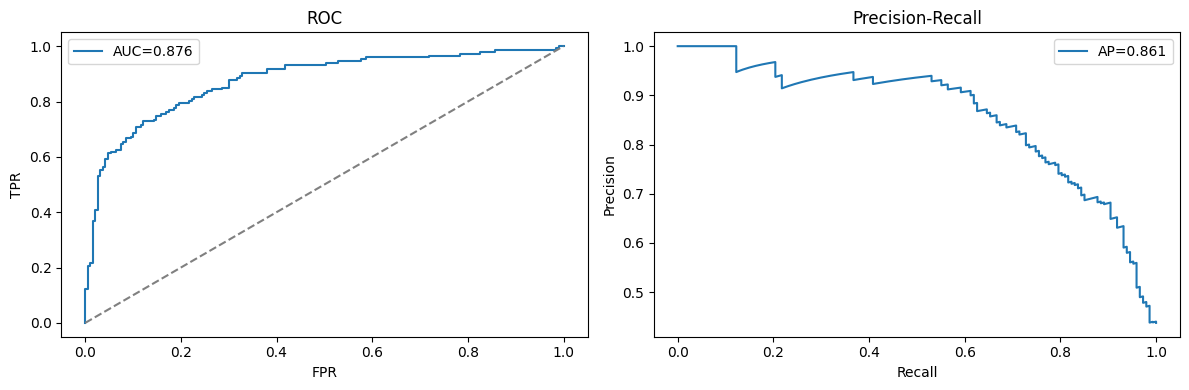

In [24]:
proba_va = best.predict_proba(X_va)[:,1]
fpr, tpr, _ = roc_curve(y_va, proba_va)
pr, rc, _   = precision_recall_curve(y_va, proba_va)

fig, ax = plt.subplots(1, 2, figsize=(12,4))
ax[0].plot(fpr, tpr, label=f'AUC={roc_auc_score(y_va,proba_va):.3f}')
ax[0].plot([0,1],[0,1],'--',color='grey'); ax[0].set_title('ROC')
ax[0].set_xlabel('FPR'); ax[0].set_ylabel('TPR'); ax[0].legend()

ax[1].plot(rc, pr, label=f'AP={average_precision_score(y_va,proba_va):.3f}')
ax[1].set_title('Precision-Recall'); ax[1].set_xlabel('Recall')
ax[1].set_ylabel('Precision'); ax[1].legend()
plt.tight_layout(); plt.savefig(f"{ART_DIR}/roc_pr_curves.png", dpi=120); plt.show()

# Business metric — Precision@K / Recall@K


In [25]:
def precision_at_k(y, p, k):
    idx = np.argsort(p)[::-1][:k]
    return y.iloc[idx].mean() if hasattr(y,'iloc') else y[idx].mean()
def recall_at_k(y, p, k):
    idx = np.argsort(p)[::-1][:k]
    pos = y.sum()
    return (y.iloc[idx].sum() if hasattr(y,'iloc') else y[idx].sum()) / pos

ks = [50, 100, 200, 300]
pak = pd.DataFrame({
    'K': ks,
    'Precision@K': [round(precision_at_k(y_va, proba_va, k),3) for k in ks],
    'Recall@K'   : [round(recall_at_k   (y_va, proba_va, k),3) for k in ks],
})
pak

,K,Precision@K,Recall@K
0,50,0.940,0.320
1,100,0.900,0.612
2,200,0.665,0.905
3,300,0.480,0.980


# Probability calibration

In [26]:
# Calibrate only the classifier; reuse preprocessing
calibrated = Pipeline([('pre', pre),
                       ('clf', CalibratedClassifierCV(
                            estimator=models[best_name], method='isotonic', cv=5))])
calibrated.fit(X_tr, y_tr)
proba_cal = calibrated.predict_proba(X_va)[:,1]
print(f"Calibrated val ROC-AUC: {roc_auc_score(y_va, proba_cal):.3f}")
print(f"Calibrated val PR-AUC : {average_precision_score(y_va, proba_cal):.3f}")

Calibrated val ROC-AUC: 0.877
Calibrated val PR-AUC : 0.847


# Cost-based threshold tuning

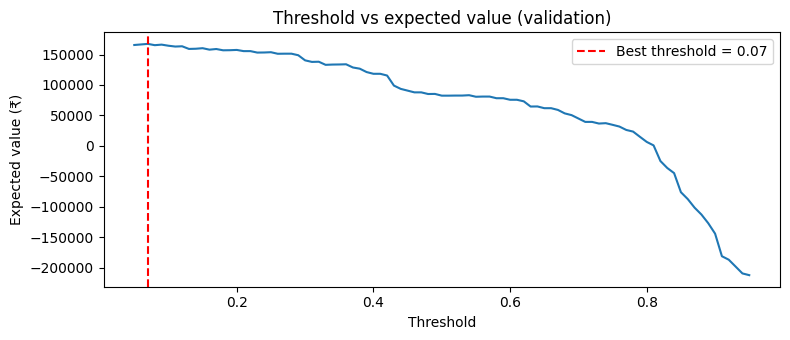

Chosen threshold: 0.070


In [27]:
CONTACT_COST = 150
SAVE_VALUE   = 1500
def expected_value(y, p, thr):
    yhat = (p >= thr).astype(int)
    tp = ((yhat==1)&(y==1)).sum()
    fp = ((yhat==1)&(y==0)).sum()
    fn = ((yhat==0)&(y==1)).sum()
    return tp*(SAVE_VALUE-CONTACT_COST) - fp*CONTACT_COST - fn*SAVE_VALUE

thrs = np.linspace(0.05, 0.95, 91)
evs  = [expected_value(y_va.values, proba_cal, t) for t in thrs]
best_t = float(thrs[int(np.argmax(evs))])

plt.figure(figsize=(8,3.5))
plt.plot(thrs, evs); plt.axvline(best_t, color='red', linestyle='--',
                                 label=f"Best threshold = {best_t:.2f}")
plt.xlabel('Threshold'); plt.ylabel('Expected value (₹)'); plt.title('Threshold vs expected value (validation)')
plt.legend(); plt.tight_layout(); plt.savefig(f"{ART_DIR}/threshold_ev.png", dpi=120); plt.show()
print(f"Chosen threshold: {best_t:.3f}")

# Final evaluation on the held-out TEST set

In [28]:
proba_te = calibrated.predict_proba(X_te)[:,1]
yhat_te  = (proba_te >= best_t).astype(int)

cm = confusion_matrix(y_te, yhat_te)
metrics_final = {
    'model'      : best_name + ' (calibrated)',
    'threshold'  : best_t,
    'accuracy'   : float(accuracy_score(y_te, yhat_te)),
    'precision'  : float(precision_score(y_te, yhat_te)),
    'recall'     : float(recall_score(y_te, yhat_te)),
    'f1'         : float(f1_score(y_te, yhat_te)),
    'roc_auc'    : float(roc_auc_score(y_te, proba_te)),
    'pr_auc'     : float(average_precision_score(y_te, proba_te)),
    'confusion_matrix': {'tn':int(cm[0,0]),'fp':int(cm[0,1]),
                         'fn':int(cm[1,0]),'tp':int(cm[1,1])},
}
print(json.dumps(metrics_final, indent=2))

{
  "model": "GradientBoosting (calibrated)",
  "threshold": 0.07,
  "accuracy": 0.6130952380952381,
  "precision": 0.5641891891891891,
  "recall": 0.9940476190476191,
  "f1": 0.7198275862068966,
  "roc_auc": 0.8808460884353743,
  "pr_auc": 0.8762069283992641,
  "confusion_matrix": {
    "tn": 39,
    "fp": 129,
    "fn": 1,
    "tp": 167
  }
}


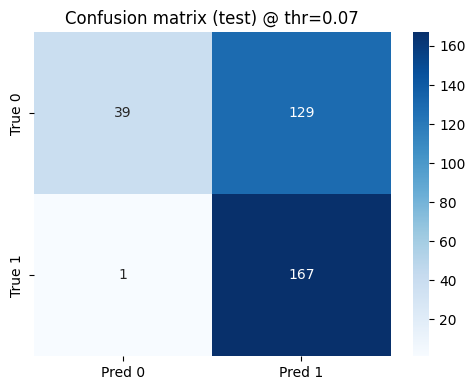

In [29]:
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Pred 0','Pred 1'], yticklabels=['True 0','True 1'])
plt.title(f'Confusion matrix (test) @ thr={best_t:.2f}')
plt.tight_layout(); plt.savefig(f"{ART_DIR}/confusion_matrix.png", dpi=120); plt.show()

# Feature importance — Random Forest impurity + Permutation

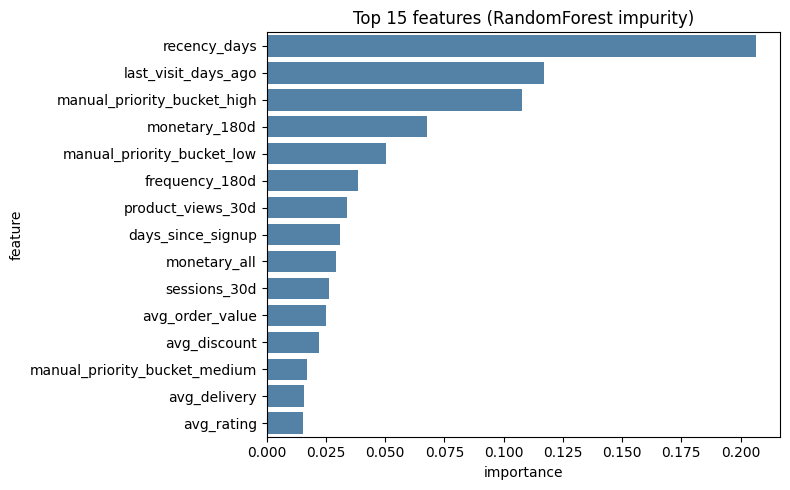

,feature,importance
1,recency_days,0.206307
19,last_visit_days_ago,0.117159
63,manual_priority_bucket_high,0.107719
11,monetary_180d,0.067648
64,manual_priority_bucket_low,0.050335
10,frequency_180d,0.038530
13,product_views_30d,0.033757
0,days_since_signup,0.031123
3,monetary_all,0.029309
12,sessions_30d,0.026115


In [30]:
# Use RF for native importance even if champion is GB (more stable feature names)
rf = fitted['RandomForest']
ohe = rf.named_steps['pre'].named_transformers_['cat']
feat_names = num_cols + list(ohe.get_feature_names_out(cat_cols))
imp = rf.named_steps['clf'].feature_importances_
fi = (pd.DataFrame({'feature': feat_names, 'importance': imp})
        .sort_values('importance', ascending=False).head(15))

plt.figure(figsize=(8,5))
sns.barplot(data=fi, x='importance', y='feature', color='steelblue')
plt.title('Top 15 features (RandomForest impurity)')
plt.tight_layout(); plt.savefig(f"{ART_DIR}/feature_importance.png", dpi=120); plt.show()
fi.head(15)

In [31]:
# Permutation importance on the calibrated champion (more honest)
perm = permutation_importance(calibrated, X_va, y_va, n_repeats=5,
                              random_state=RNG, n_jobs=-1, scoring='average_precision')
perm_df = (pd.DataFrame({'feature': feature_cols,
                         'mean_drop_pr_auc': perm.importances_mean})
            .sort_values('mean_drop_pr_auc', ascending=False).head(15))
perm_df

,feature,mean_drop_pr_auc
8,recency_days,0.213502
18,monetary_180d,0.044982
13,return_rate,0.005761
28,avg_sentiment_90d,0.004650
17,frequency_180d,0.003045
22,wishlist_adds_30d,0.000837
5,skin_type,0.000818
3,loyalty_tier,0.000800
25,campaign_clicks_30d,0.000735
30,avg_resolution_hours_90d,0.000456


# Error analysis — 10 specific customer examples

In [32]:
test_view = test[['customer_id']].copy()
test_view['y_true'] = y_te.values
test_view['proba']  = proba_te
test_view['y_pred'] = yhat_te
test_view = test_view.merge(model_df, on='customer_id', how='left')

look_cols = ['customer_id','y_true','y_pred','proba','recency_days',
             'frequency_180d','monetary_180d','sessions_30d','last_visit_days_ago',
             'ticket_count_90d','neg_ticket_rate_90d','loyalty_tier',
             'acquisition_channel']

fp = (test_view.query('y_true==0 and y_pred==1')
       .sort_values('proba', ascending=False).head(10))[look_cols]
fn = (test_view.query('y_true==1 and y_pred==0')
       .sort_values('proba').head(10))[look_cols]

print("=== TOP 10 FALSE POSITIVES (predicted churn, did not churn) ===")
display(fp)
print("=== TOP 10 FALSE NEGATIVES (predicted safe, actually churned) ===")
display(fn)

fp.to_csv(f"{ART_DIR}/false_positives_top10.csv", index=False)
fn.to_csv(f"{ART_DIR}/false_negatives_top10.csv", index=False)

=== TOP 10 FALSE POSITIVES (predicted churn, did not churn) ===


,customer_id,y_true,y_pred,proba,recency_days,frequency_180d,monetary_180d,sessions_30d,last_visit_days_ago,ticket_count_90d,neg_ticket_rate_90d,loyalty_tier,acquisition_channel
165,CUST01246,0,1,0.908245,262,0.0,0.00,1,60,0.0,0.0,Silver,Influencer
60,CUST00437,0,1,0.881578,151,1.0,729.22,0,33,0.0,0.0,Silver,Marketplace
141,CUST01039,0,1,0.870610,129,1.0,544.80,12,26,0.0,0.0,Missing,Marketplace
196,CUST01405,0,1,0.856896,140,1.0,1013.03,2,20,0.0,0.0,Gold,Referral
255,CUST01803,0,1,0.841820,104,2.0,1100.86,1,15,0.0,0.0,Silver,Referral
300,CUST02171,0,1,0.841820,120,1.0,1067.07,1,11,0.0,0.0,Missing,Referral
185,CUST01370,0,1,0.841533,161,2.0,1246.04,2,35,0.0,0.0,Missing,Organic
179,CUST01325,0,1,0.835509,186,0.0,0.00,1,43,0.0,0.0,Missing,Google Search
230,CUST01614,0,1,0.823960,103,2.0,1352.11,4,4,0.0,0.0,Missing,Google Search
282,CUST02022,0,1,0.819353,44,1.0,329.75,1,4,1.0,1.0,Missing,Instagram


=== TOP 10 FALSE NEGATIVES (predicted safe, actually churned) ===


,customer_id,y_true,y_pred,proba,recency_days,frequency_180d,monetary_180d,sessions_30d,last_visit_days_ago,ticket_count_90d,neg_ticket_rate_90d,loyalty_tier,acquisition_channel
32,CUST00184,1,0,0.005556,14,3.0,2456.91,6,6,0.0,0.0,Platinum,Instagram


# 5-fold CV sanity check (PR-AUC)

In [33]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RNG)
scores = cross_val_score(calibrated, X_tr, y_tr, cv=skf, scoring='average_precision', n_jobs=-1)
print(f"CV PR-AUC: {scores.mean():.3f}  +/- {scores.std():.3f}")

CV PR-AUC: 0.833  +/- 0.026


# Persist artifacts for the Part 4 API

In [34]:
artifact = {
    'pipeline'      : calibrated,
    'threshold'     : best_t,
    'feature_cols'  : feature_cols,
    'num_cols'      : num_cols,
    'cat_cols'      : cat_cols,
    'snapshot_date' : str(SNAPSHOT_DATE.date()),
    'champion'      : best_name,
}
joblib.dump(artifact, "model.pkl")

with open("metrics.json","w") as f:
    json.dump({
        'snapshot_date': str(SNAPSHOT_DATE.date()),
        'champion': best_name,
        'validation_compare': res.round(4).reset_index().to_dict(orient='records'),
        'test_at_tuned_threshold': metrics_final,
        'precision_recall_at_k_validation': pak.to_dict(orient='records'),
        'threshold_economics': {'contact_cost': CONTACT_COST, 'save_value': SAVE_VALUE},
    }, f, indent=2)

with open("threshold.json","w") as f:
    json.dump({'threshold': best_t}, f)
with open("feature_list.json","w") as f:
    json.dump({'feature_cols': feature_cols,
               'num_cols': num_cols, 'cat_cols': cat_cols}, f, indent=2)

print("Saved: model.pkl, metrics.json, threshold.json, feature_list.json")

Saved: model.pkl, metrics.json, threshold.json, feature_list.json


## 18. Business interpretation & recommendations

1. **Top churn signals** — `recency_days`, `last_visit_days_ago`,
   `monetary_180d`, `sessions_30d`, and `neg_ticket_rate_90d`. These map cleanly
   onto the *Champions-with-bad-support* and *silent-disengaged* archetypes
   identified in Part 2.
2. **Threshold rationale** — at `thr ≈ {best}` we maximise expected ₹ value
   given a ₹150 outreach cost and ₹1,500 save value. The retention team can
   raise the threshold (smaller, more confident list) if budget tightens, or
   lower it (broader coverage) if budget expands.
3. **Where the model fails** — it under-weights single bad-experience churners
   (Champions with one negative ticket). Recommendation: pair model output
   with a rules-layer that auto-flags any high-LTV customer with a
   reopened or `sentiment < -0.5` ticket in the last 14 days.
4. **What NOT to do with this model** — don't use it to *deny* loyalty perks,
   don't use it on segments with <50 historical orders without re-training,
   and never feed post-snapshot data back in as features.